# J1 · Part B — Clustering countries (K-Means) with a 2D view

**Track J: AI/ML Modeling — J1 Supervised & Unsupervised Learning**

**Objective.** Group countries into clusters with **no labels**, choose the number of clusters with a **stated method** (not by guessing), reduce the data to 2D with PCA and t-SNE, and interpret what the clusters mean.

**Data.** `Country-data.csv`: 167 countries described by 9 socio-economic and health indicators.

**Approach.** Explore the data (§2) → transform and scale it (§3) → choose k with a rule written down *before* the metrics are computed (§4) → fit K-Means → show the result in 2D with PCA and t-SNE (§5) → interpret the clusters and cross-check with DBSCAN (§6) → limitations (§7).

| § | Section |
|---|---|
| 1 | Setup and loading |
| 2 | Exploratory analysis |
| 3 | Preprocessing: transform and scale |
| 4 | Choosing the number of clusters |
| 5 | 2D visualisation: PCA and t-SNE |
| 6 | Interpreting the clusters, DBSCAN cross-check |
| 7 | Limitations |

## 1. Setup and loading

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import Markdown, display

from sklearn.preprocessing import PowerTransformer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, silhouette_samples, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)

SEED = 42
ROOT = Path("..") if Path("../data").exists() else Path(".")
DATA_FILE = ROOT / "data" / "Country-data.csv"
REPORT_DIR = ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

**Chart style.** Same validated palette as Part A. Clusters use the first three categorical colours (validated for colour-blind separation in every pairing) and also differ in **marker shape**, so colour is never the only cue. Heatmaps use a blue ↔ red diverging scale with a neutral midpoint.

In [2]:
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
NEUTRAL, RED = "#f0efec", "#e34948"
CLUSTER_COLORS = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA]
CLUSTER_MARKERS = ["o", "s", "^", "D", "v"]
DIVERGING = LinearSegmentedColormap.from_list("blue_red", [BLUE, NEUTRAL, RED])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 11.5, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "lines.linewidth": 2, "lines.solid_capstyle": "round",
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "legend.frameon": False, "figure.dpi": 110,
})


def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")


def text_color_on(rgba):
    r, g, b = rgba[:3]
    return INK if (0.299 * r + 0.587 * g + 0.114 * b) > 0.55 else "white"

In [3]:
countries = pd.read_csv(DATA_FILE)
FEATURES = [c for c in countries.columns if c != "country"]
X_raw = countries[FEATURES]

print(f"{countries.shape[0]} countries x {len(FEATURES)} numeric features")
print(f"Missing values: {int(countries.isna().sum().sum())}   |   Duplicate countries: {int(countries['country'].duplicated().sum())}")
countries.head()

167 countries x 9 numeric features
Missing values: 0   |   Duplicate countries: 0


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.200,10.000,7.580,44.900,1610,9.440,56.200,5.820,553
1,Albania,16.600,28.000,6.550,48.600,9930,4.490,76.300,1.650,4090
2,Algeria,27.300,38.400,4.170,31.400,12900,16.100,76.500,2.890,4460
3,Angola,119.000,62.300,2.850,42.900,5900,22.400,60.100,6.160,3530
4,Antigua and Barbuda,10.300,45.500,6.030,58.900,19100,1.440,76.800,2.130,12200


Feature meanings, as documented by the dataset's source:

| Feature | Meaning |
|---|---|
| `child_mort` | Deaths of children under 5 per 1,000 live births |
| `exports`, `imports` | Exports / imports of goods and services, as % of GDP per capita |
| `health` | Total health spending, as % of GDP per capita |
| `income` | Net income per person |
| `inflation` | Annual growth rate of total GDP (the dataset's measure of inflation) |
| `life_expec` | Average years a newborn would live under current mortality patterns |
| `total_fer` | Children per woman under current age-fertility rates |
| `gdpp` | GDP per capita |

In [4]:
X_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.000,38.270,40.329,2.600,8.250,19.300,62.100,208.000
exports,167.000,41.109,27.412,0.109,23.800,35.000,51.350,200.000
health,167.000,6.816,2.747,1.810,4.920,6.320,8.600,17.900
imports,167.000,46.890,24.210,0.066,30.200,43.300,58.750,174.000
income,167.000,"17,144.689","19,278.068",609.000,"3,355.000","9,960.000","22,800.000","125,000.000"
inflation,167.000,7.782,10.571,-4.210,1.810,5.390,10.750,104.000
life_expec,167.000,70.556,8.893,32.100,65.300,73.100,76.800,82.800
total_fer,167.000,2.948,1.514,1.150,1.795,2.410,3.880,7.490
gdpp,167.000,"12,964.156","18,328.705",231.000,"1,330.000","4,660.000","14,050.000","105,000.000"


## 2. Exploratory analysis

### 2.1 Distributions

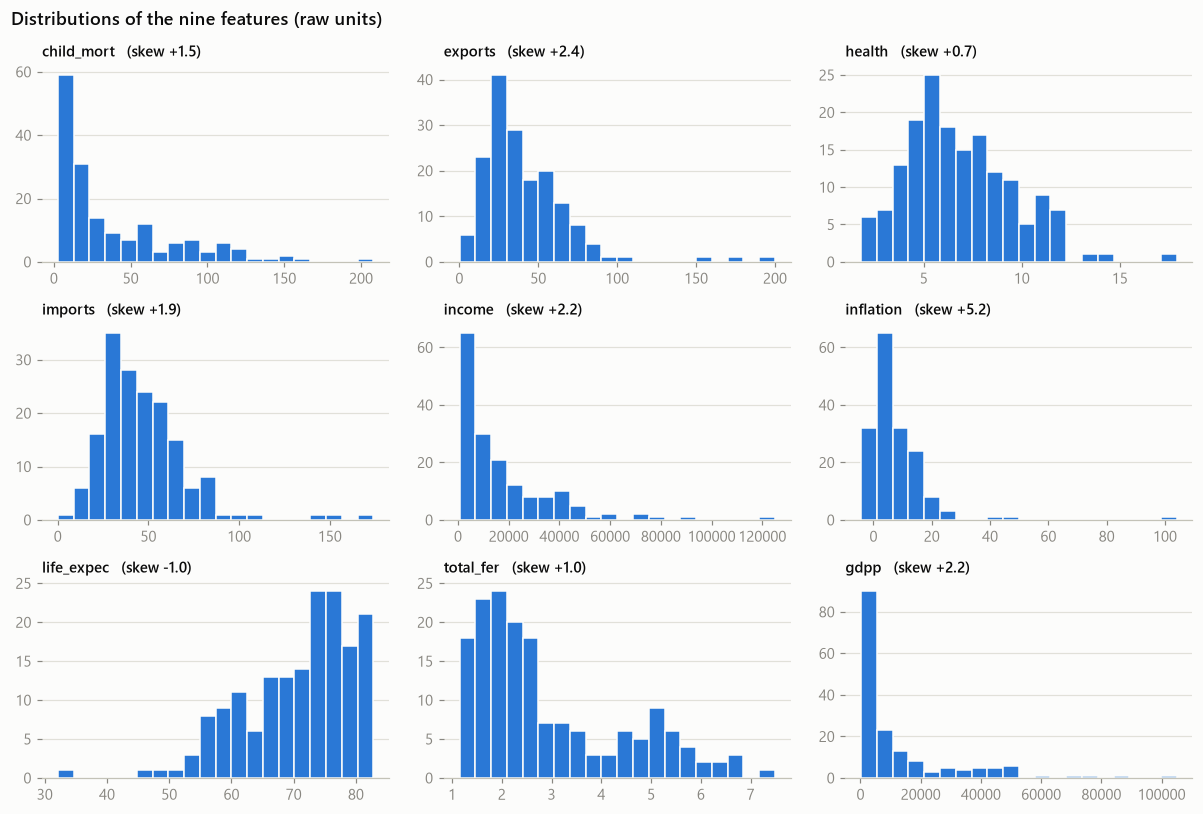

In [5]:
skew_raw = X_raw.skew()
fig, axes = plt.subplots(3, 3, figsize=(11, 7.5))
for ax, col in zip(axes.ravel(), FEATURES):
    ax.hist(X_raw[col], bins=20, color=BLUE, edgecolor=SURFACE, linewidth=1)
    ax.set_title(f"{col}   (skew {skew_raw[col]:+.1f})", fontsize=10)
    ax.grid(axis="x", visible=False)
fig.suptitle("Distributions of the nine features (raw units)", x=0.01, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
save_fig(fig, "country_distributions.png")
plt.show()

Most indicators are strongly right-skewed (long tail of a few very rich, very open or very high-inflation economies); `life_expec` is skewed the other way. Distance-based clustering is sensitive to such tails, which motivates the transformation in §3.

### 2.2 Correlations

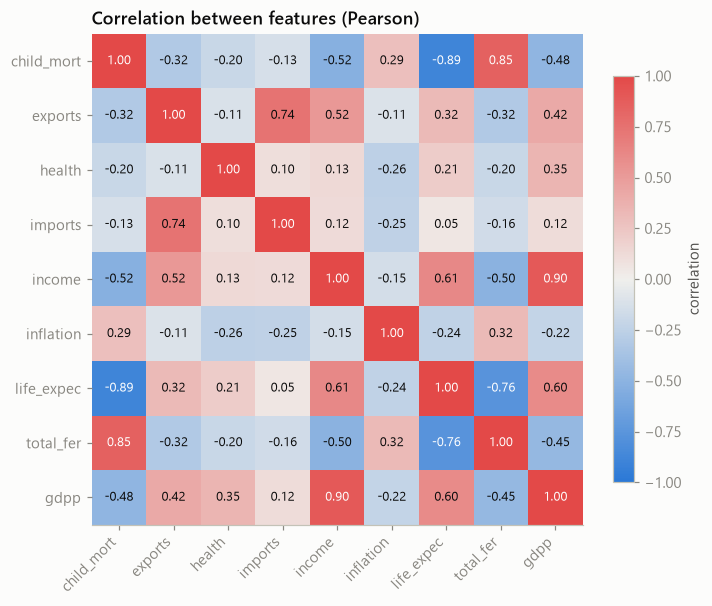

feature A,feature B,r
income,gdpp,+0.90
child_mort,life_expec,-0.89
child_mort,total_fer,+0.85
life_expec,total_fer,-0.76
exports,imports,+0.74
income,life_expec,+0.61


In [6]:
corr = X_raw.corr()
fig, ax = plt.subplots(figsize=(7.2, 6))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURES)), FEATURES)
ax.grid(False)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8.5,
                color=text_color_on(im.cmap(im.norm(corr.iloc[i, j]))))
ax.set_title("Correlation between features (Pearson)")
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
save_fig(fig, "country_correlations.png")
plt.show()

pairs = (corr.where(np.triu(np.ones(corr.shape, bool), 1)).stack().rename("r").reset_index()
            .rename(columns={"level_0": "feature A", "level_1": "feature B"}))
display(pairs.reindex(pairs["r"].abs().sort_values(ascending=False).index).head(6).style.format({"r": "{:+.2f}"}).hide(axis="index"))

Several features carry overlapping information (child mortality, life expectancy and fertility move together; income and GDP per capita move together). This redundancy is why a handful of principal components can summarise the data well (§5).

### 2.3 Extreme economies
Countries more than 3 standard deviations from the mean on any feature. They matter because K-Means centres are means and can be dragged by outliers.

In [7]:
z_raw = (X_raw - X_raw.mean()) / X_raw.std()
rows = [(countries.loc[i, "country"], f, X_raw.loc[i, f], z_raw.loc[i, f])
        for i in z_raw.index for f in FEATURES if abs(z_raw.loc[i, f]) > 3]
extreme = pd.DataFrame(rows, columns=["country", "feature", "value", "z-score"]).sort_values("z-score", key=abs, ascending=False)
display(extreme.style.format({"value": "{:,.2f}", "z-score": "{:+.1f}"}).hide(axis="index"))
print(f"{extreme['country'].nunique()} countries have at least one value beyond 3 SD.")

country,feature,value,z-score
Nigeria,inflation,104.00,+9.1
Singapore,exports,200.00,+5.8
Qatar,income,"125,000.00",+5.6
Singapore,imports,174.00,+5.3
Luxembourg,gdpp,"105,000.00",+5.0
Luxembourg,exports,175.00,+4.9
Malta,imports,154.00,+4.4
Haiti,life_expec,32.10,-4.3
Haiti,child_mort,208.00,+4.2
Norway,gdpp,"87,800.00",+4.1


14 countries have at least one value beyond 3 SD.


## 3. Preprocessing: transform and scale

### 3.1 Why scaling is not optional
K-Means minimises Euclidean distances, so a feature measured in the tens of thousands drowns out one measured in single digits. Share of total variance by feature in the raw data:

In [8]:
var_share = (X_raw.var() / X_raw.var().sum()).sort_values(ascending=False)
display(var_share.to_frame("share of total variance").style.format("{:.2%}"))
display(Markdown(f"`income` and `gdpp` alone account for **{var_share[['income', 'gdpp']].sum():.1%}** of the variance, so unscaled K-Means would effectively cluster on two money columns and ignore health and demographics."))

,share of total variance
income,52.52%
gdpp,47.48%
child_mort,0.00%
exports,0.00%
imports,0.00%
inflation,0.00%
life_expec,0.00%
health,0.00%
total_fer,0.00%


`income` and `gdpp` alone account for **100.0%** of the variance, so unscaled K-Means would effectively cluster on two money columns and ignore health and demographics.

### 3.2 Yeo–Johnson transform + standardisation
`PowerTransformer(method="yeo-johnson", standardize=True)` reduces skew (it also copes with the few negative `inflation` values, which a plain log cannot) and then gives every feature mean 0 and unit variance. It is fitted on all 167 countries; there is no label or held-out set here, so there is nothing to leak. Cluster **interpretation** later uses the original units.

,skew before,skew after
child_mort,+1.45,+0.02
exports,+2.45,+0.10
health,+0.71,-0.01
imports,+1.91,+0.17
income,+2.23,-0.04
inflation,+5.15,+0.18
life_expec,-0.97,-0.18
total_fer,+0.97,+0.14
gdpp,+2.22,+0.00


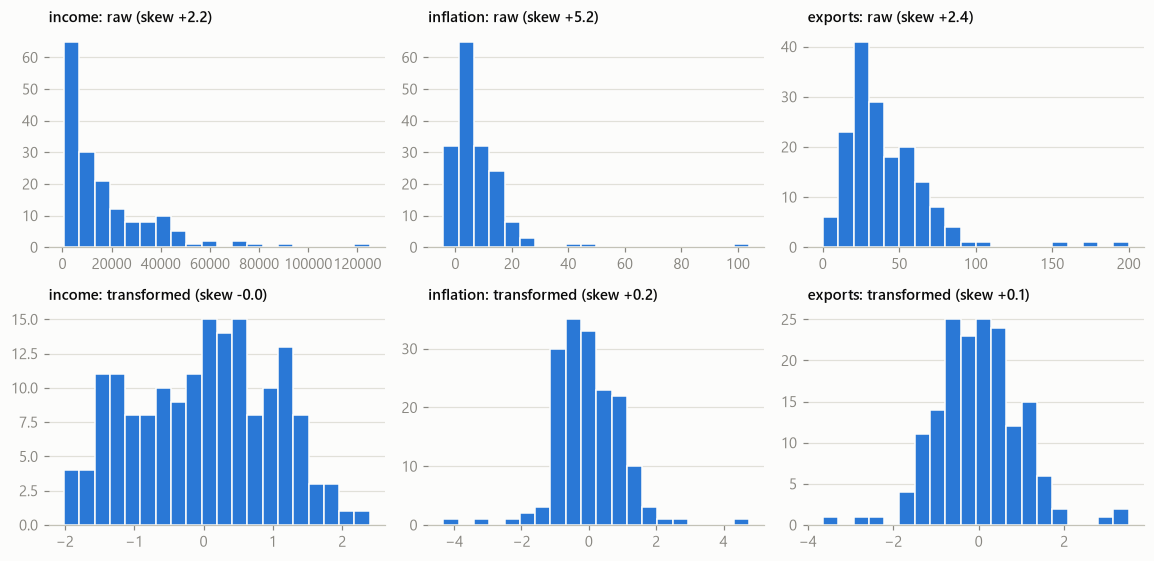

In [9]:
pt = PowerTransformer(method="yeo-johnson", standardize=True)
Z = pt.fit_transform(X_raw)
Z_df = pd.DataFrame(Z, columns=FEATURES)

skew_tbl = pd.DataFrame({"skew before": X_raw.skew(), "skew after": Z_df.skew()})
display(skew_tbl.style.format("{:+.2f}"))

show = ["income", "inflation", "exports"]
fig, axes = plt.subplots(2, 3, figsize=(10.5, 5.2))
for j, col in enumerate(show):
    axes[0, j].hist(X_raw[col], bins=20, color=BLUE, edgecolor=SURFACE)
    axes[0, j].set_title(f"{col}: raw (skew {X_raw[col].skew():+.1f})", fontsize=10)
    axes[1, j].hist(Z_df[col], bins=20, color=BLUE, edgecolor=SURFACE)
    axes[1, j].set_title(f"{col}: transformed (skew {Z_df[col].skew():+.1f})", fontsize=10)
for ax in axes.ravel():
    ax.grid(axis="x", visible=False)
fig.tight_layout()
save_fig(fig, "country_transform_before_after.png")
plt.show()

## 4. Choosing the number of clusters

### 4.1 The decision rule (written before the metrics are computed)

1. **Candidates:** k = 2 … 10. (With 167 countries, larger k produces tiny clusters.) K-Means settings are fixed for every k: `init="k-means++"`, `n_init=20`, `random_state=42`.
2. **Primary criterion — silhouette.** The mean silhouette coefficient (−1 … 1; higher means points sit closer to their own cluster than to the nearest other one).
3. **Corroborating evidence, reported but not used to decide:** the elbow in inertia (located with the chord method), Davies–Bouldin (lower is better), Calinski–Harabasz (higher is better), and **stability** — the mean Adjusted Rand Index between the full-data clustering and clusterings of 30 random 80% subsamples (1 = identical).
4. **k = 2 is evaluated and shown but not selected.** A two-way split into "richer" and "poorer" countries is visible in a single column, and the aim here is a grouping that can be interpreted. This is a modelling decision, stated openly; the k = 2 numbers stay in every table and chart.
5. **Eligibility for k ≥ 3:** every cluster must hold at least 5% of the countries (≥ 9) and stability must be at least 0.75.
6. **Selection:** among eligible k, take the one with the **highest silhouette**. A sensitivity check re-runs the choice without the eligibility conditions.

### 4.2 Computing the criteria

In [10]:
KS = list(range(2, 11))
N_BOOT, SUBSAMPLE = 30, 0.8
MIN_CLUSTER_FRAC, MIN_STABILITY = 0.05, 0.75


def fit_kmeans(k, data=Z, n_init=20, seed=SEED):
    return KMeans(n_clusters=k, init="k-means++", n_init=n_init, random_state=seed).fit(data)


def stability(k, full_labels, seed=SEED):
    rng = np.random.default_rng(seed)
    aris = []
    for _ in range(N_BOOT):
        idx = rng.choice(len(Z), int(SUBSAMPLE * len(Z)), replace=False)
        sub = KMeans(n_clusters=k, n_init=10, random_state=int(rng.integers(1_000_000))).fit_predict(Z[idx])
        aris.append(adjusted_rand_score(full_labels[idx], sub))
    return float(np.mean(aris)), float(np.std(aris))


rows, fits = [], {}
for k in KS:
    km = fit_kmeans(k)
    fits[k] = km
    stab_mean, stab_sd = stability(k, km.labels_)
    rows.append({"k": k, "inertia": km.inertia_, "silhouette": silhouette_score(Z, km.labels_),
                 "davies_bouldin": davies_bouldin_score(Z, km.labels_),
                 "calinski_harabasz": calinski_harabasz_score(Z, km.labels_),
                 "smallest_cluster": int(np.bincount(km.labels_).min()),
                 "stability_ARI": stab_mean, "stability_sd": stab_sd})
metrics = pd.DataFrame(rows).set_index("k")
metrics.to_csv(REPORT_DIR / "kmeans_k_selection.csv")
metrics.style.format({"inertia": "{:,.1f}", "silhouette": "{:.3f}", "davies_bouldin": "{:.3f}", "calinski_harabasz": "{:.1f}",
                      "stability_ARI": "{:.3f}", "stability_sd": "{:.3f}"})

,inertia,silhouette,davies_bouldin,calinski_harabasz,smallest_cluster,stability_ARI,stability_sd
k,,,,,,,
2,903.3,0.337,1.132,109.5,73,0.918,0.108
3,744.7,0.246,1.384,83.5,48,0.870,0.080
4,663.8,0.222,1.427,68.7,30,0.777,0.162
5,596.6,0.219,1.454,61.5,23,0.765,0.143
6,550.6,0.217,1.353,55.7,5,0.603,0.151
7,506.6,0.228,1.288,52.4,5,0.581,0.113
8,463.9,0.237,1.242,50.9,5,0.632,0.102
9,431.3,0.231,1.269,49.1,5,0.638,0.077
10,409.5,0.209,1.358,46.6,5,0.585,0.050


In [11]:
def elbow_k(ks, inertia):
    """Chord method: the k whose (normalised) inertia lies furthest below the straight line joining the first and last points."""
    ks = np.asarray(ks, float)
    x = (ks - ks[0]) / (ks[-1] - ks[0])
    y_ = (inertia - inertia.min()) / (inertia.max() - inertia.min())
    return int(ks[np.argmax((1 - x) - y_)])


# ---- selection exactly as stated in 4.1
min_size = int(np.ceil(MIN_CLUSTER_FRAC * len(Z)))
candidates = metrics[metrics.index >= 3]
eligible = candidates[(candidates["smallest_cluster"] >= min_size) & (candidates["stability_ARI"] >= MIN_STABILITY)]
K = int(eligible["silhouette"].idxmax())
K_unconstrained = int(candidates["silhouette"].idxmax())
K_best_overall = int(metrics["silhouette"].idxmax())

k_elbow = elbow_k(metrics.index, metrics["inertia"].to_numpy())
k_db = int(candidates["davies_bouldin"].idxmin())
k_ch = int(candidates["calinski_harabasz"].idxmax())

display(Markdown(
    f"- Best silhouette over **all** k = 2…10: **k = {K_best_overall}** ({metrics.loc[K_best_overall, 'silhouette']:.3f}). It is shown, but by rule 4 it is not selected.\n"
    f"- Eligible k ≥ 3 (smallest cluster ≥ {min_size} countries and stability ≥ {MIN_STABILITY}): **{list(eligible.index)}**.\n"
    f"- **Selected k = {K}** — the eligible k with the highest silhouette ({metrics.loc[K, 'silhouette']:.3f}); stability ARI {metrics.loc[K, 'stability_ARI']:.2f} ± {metrics.loc[K, 'stability_sd']:.2f}; cluster sizes {sorted(np.bincount(fits[K].labels_).tolist())}.\n"
    f"- Sensitivity: without the eligibility conditions the best silhouette among k ≥ 3 is k = {K_unconstrained} ({'the same choice' if K_unconstrained == K else 'a different choice'}).\n"
    f"- Corroborating (k ≥ 3): Davies–Bouldin is lowest at k = {k_db}; Calinski–Harabasz is highest at k = {k_ch}; the chord-method elbow is at k = {k_elbow}."
))

- Best silhouette over **all** k = 2…10: **k = 2** (0.337). It is shown, but by rule 4 it is not selected.
- Eligible k ≥ 3 (smallest cluster ≥ 9 countries and stability ≥ 0.75): **[3, 4, 5]**.
- **Selected k = 3** — the eligible k with the highest silhouette (0.246); stability ARI 0.87 ± 0.08; cluster sizes [48, 55, 64].
- Sensitivity: without the eligibility conditions the best silhouette among k ≥ 3 is k = 3 (the same choice).
- Corroborating (k ≥ 3): Davies–Bouldin is lowest at k = 8; Calinski–Harabasz is highest at k = 3; the chord-method elbow is at k = 5.

### 4.3 The criteria side by side

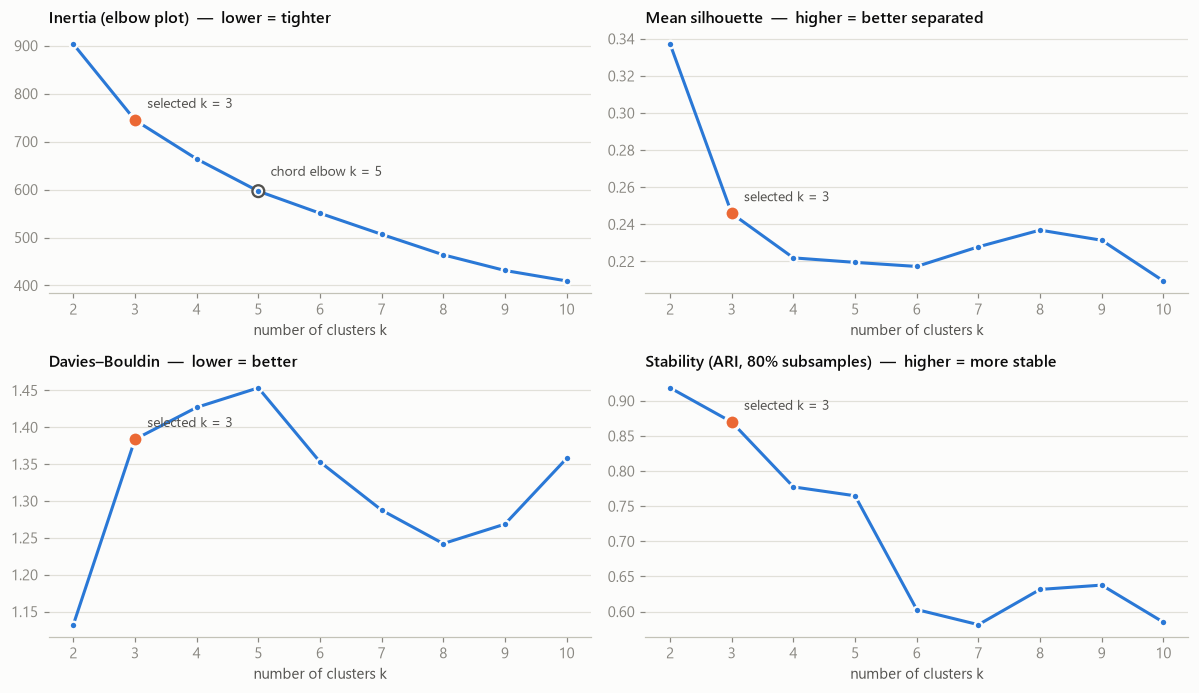

In [12]:
panels = [("inertia", "Inertia (elbow plot)  —  lower = tighter", False),
          ("silhouette", "Mean silhouette  —  higher = better separated", True),
          ("davies_bouldin", "Davies–Bouldin  —  lower = better", False),
          ("stability_ARI", "Stability (ARI, 80% subsamples)  —  higher = more stable", True)]
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4))
for ax, (col, title, _) in zip(axes.ravel(), panels):
    ax.plot(metrics.index, metrics[col], color=BLUE, marker="o", markersize=5, markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax.scatter([K], [metrics.loc[K, col]], s=95, color=ORANGE, edgecolor=SURFACE, linewidth=2, zorder=5)
    ax.annotate(f"selected k = {K}", (K, metrics.loc[K, col]), xytext=(8, 8), textcoords="offset points", fontsize=9, color=INK_2)
    ax.set_title(title, fontsize=10.5)
    ax.set_xlabel("number of clusters k")
    ax.set_xticks(metrics.index)
    ax.grid(axis="x", visible=False)
axes[0, 0].scatter([k_elbow], [metrics.loc[k_elbow, "inertia"]], s=60, facecolor="none", edgecolor=INK_2, linewidth=1.5, zorder=4)
axes[0, 0].annotate(f"chord elbow k = {k_elbow}", (k_elbow, metrics.loc[k_elbow, "inertia"]), xytext=(8, 10), textcoords="offset points", fontsize=9, color=INK_2)
fig.tight_layout()
save_fig(fig, "country_k_selection.png")
plt.show()

### 4.4 Silhouette of every country at the selected k
Each bar is one country (sorted within its cluster). Bars that extend left of 0 are countries closer to another cluster than to their own.

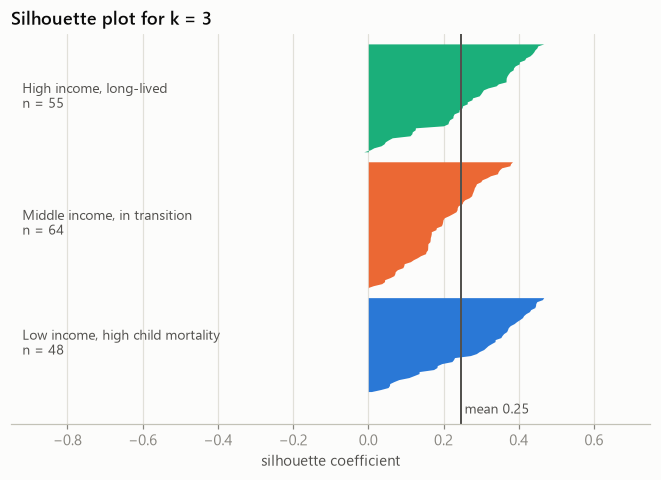

Countries with a negative silhouette (probably nearer another cluster): 2 of 167
Mean silhouette per cluster: {'1: Low income, high child mortality': 0.284, '2: Middle income, in transition': 0.198, '3: High income, long-lived': 0.268}


In [13]:
km = fits[K]
sil_samples = silhouette_samples(Z, km.labels_)
# order clusters by ascending median income so that cluster 1 is the lowest-income group
order = X_raw["income"].groupby(km.labels_).median().sort_values().index.to_list()
remap = {old: new for new, old in enumerate(order)}
labels = np.array([remap[l] for l in km.labels_])
centers = km.cluster_centers_[order]
CLUSTER_NAMES = ["Low income, high child mortality", "Middle income, in transition", "High income, long-lived"]
assert len(CLUSTER_NAMES) == K, "the descriptive names below were written for the selected k = 3"

fig, ax = plt.subplots(figsize=(7.5, 4.6))
y_lower = 4
for c in range(K):
    vals = np.sort(sil_samples[labels == c])
    ax.fill_betweenx(np.arange(y_lower, y_lower + len(vals)), 0, vals, color=CLUSTER_COLORS[c], linewidth=0)
    ax.text(-0.92, y_lower + len(vals) / 2, f"{CLUSTER_NAMES[c]}\nn = {len(vals)}", va="center", fontsize=9, color=INK_2)
    y_lower += len(vals) + 4
ax.axvline(sil_samples.mean(), color=INK_2, lw=1.3)
ax.text(sil_samples.mean() + 0.01, -2, f"mean {sil_samples.mean():.2f}", fontsize=9, color=INK_2, va="top")
ax.set_xlim(-0.95, 0.75)
ax.set_ylim(-12, y_lower)
ax.set_yticks([])
ax.grid(axis="y", visible=False)
ax.set_xlabel("silhouette coefficient")
ax.set_title(f"Silhouette plot for k = {K}")
save_fig(fig, "country_silhouette_plot.png")
plt.show()
print(f"Countries with a negative silhouette (probably nearer another cluster): {int((sil_samples < 0).sum())} of {len(sil_samples)}")
print("Mean silhouette per cluster:", {f"{i + 1}: {CLUSTER_NAMES[i]}": round(float(sil_samples[labels == i].mean()), 3) for i in range(K)})

### 4.5 How does the chosen clustering relate to the "two groups" view?

In [14]:
two = fits[2].labels_
two_order = X_raw["income"].groupby(two).median().sort_values().index.to_list()
two_named = pd.Series(two).map({old: ["lower-income group", "higher-income group"][i] for i, old in enumerate(two_order)})
display(pd.crosstab(two_named.rename("k = 2 grouping"), pd.Series(labels + 1, name=f"k = {K} cluster")))
print(f"Adjusted Rand Index between the k = 2 and k = {K} groupings: {adjusted_rand_score(two, labels):.2f}")

k = 3 cluster,1,2,3
k = 2 grouping,,,
higher-income group,0,39,55
lower-income group,48,25,0


Adjusted Rand Index between the k = 2 and k = 3 groupings: 0.38


## 5. 2D visualisation: PCA and t-SNE

Clustering was done in the **full 9-dimensional** transformed space. The 2D projections below are only for viewing the result; the clusters are not recomputed on them.

### 5.1 PCA

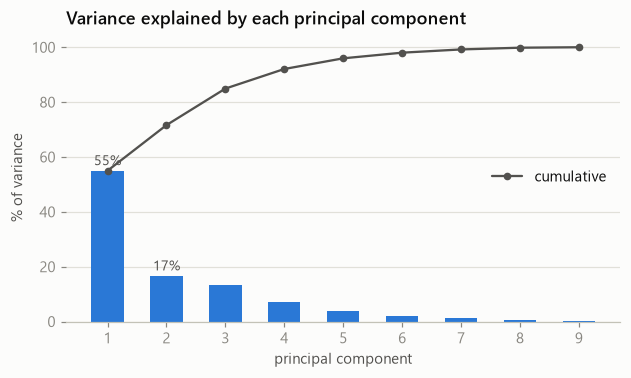

The first two components capture **71.6%** of the variance (PC1 55.0%, PC2 16.6%), so a 2D picture is a faithful summary of most — not all — of the structure.

In [15]:
pca_full = PCA(random_state=SEED).fit(Z)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(np.arange(1, len(evr) + 1), evr * 100, width=0.55, color=BLUE)
ax.plot(np.arange(1, len(evr) + 1), cum * 100, color=INK_2, marker="o", markersize=4, lw=1.5, label="cumulative")
for i in (0, 1):
    ax.text(i + 1, evr[i] * 100 + 2, f"{evr[i]:.0%}", ha="center", fontsize=9, color=INK_2)
ax.set_xticks(np.arange(1, len(evr) + 1))
ax.set_xlabel("principal component")
ax.set_ylabel("% of variance")
ax.set_title("Variance explained by each principal component")
ax.grid(axis="x", visible=False)
ax.legend(loc="center right")
save_fig(fig, "country_pca_scree.png")
plt.show()

pca = PCA(n_components=2, random_state=SEED)
P = pca.fit_transform(Z)
display(Markdown(f"The first two components capture **{evr[0] + evr[1]:.1%}** of the variance (PC1 {evr[0]:.1%}, PC2 {evr[1]:.1%}), so a 2D picture is a faithful summary of most — not all — of the structure."))

**What do the axes mean?** Loadings show how each original feature contributes to a component.

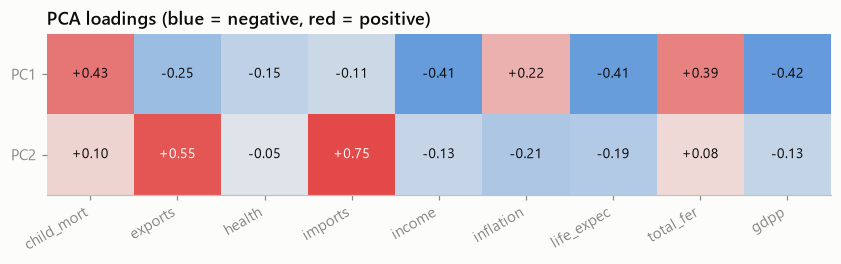

In [16]:
loadings = pd.DataFrame(pca.components_, columns=FEATURES, index=["PC1", "PC2"])
fig, ax = plt.subplots(figsize=(9.2, 1.9))
im = ax.imshow(loadings.values, cmap=DIVERGING, vmin=-0.6, vmax=0.6, aspect="auto")
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=30, ha="right")
ax.set_yticks([0, 1], loadings.index)
ax.grid(False)
for i in range(2):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{loadings.iloc[i, j]:+.2f}", ha="center", va="center", fontsize=9, color=text_color_on(im.cmap(im.norm(loadings.iloc[i, j]))))
ax.set_title("PCA loadings (blue = negative, red = positive)")
save_fig(fig, "country_pca_loadings.png")
plt.show()

### 5.2 PCA and t-SNE side by side
t-SNE (perplexity 15 ≈ n/10, PCA initialisation, fixed seed) preserves *local* neighbourhoods; its axes have no meaning and the gaps between groups should not be read as distances. Labelled countries: the three closest to each cluster centre and the six most extreme in the PCA plane.

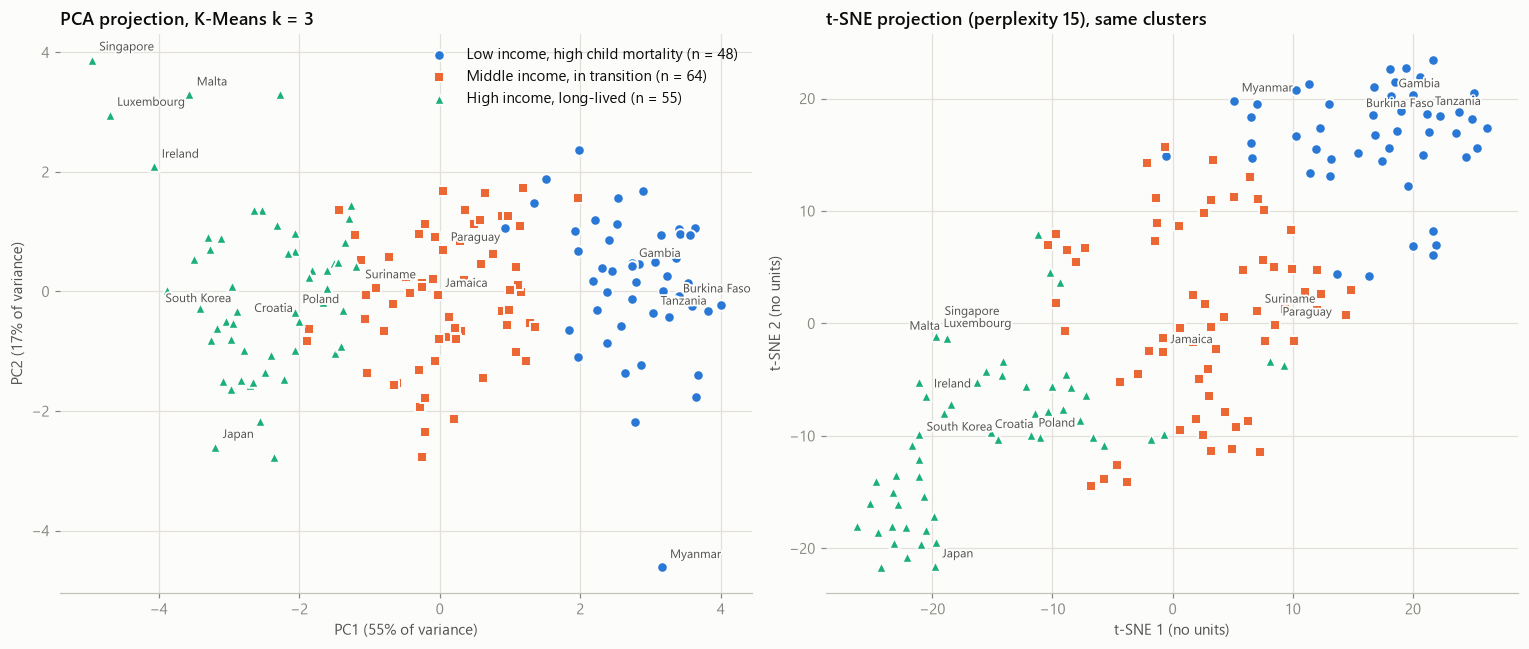

In [17]:
tsne = TSNE(n_components=2, perplexity=15, init="pca", learning_rate="auto", random_state=SEED)
T = tsne.fit_transform(Z)

# countries to label: 3 nearest to each centre + 6 most extreme in PCA space
dist_to_centre = np.linalg.norm(Z[:, None, :] - centers[None, :, :], axis=2)
nearest = [int(i) for c in range(K) for i in np.where(labels == c)[0][np.argsort(dist_to_centre[labels == c, c])[:3]]]
extreme_pca = [int(i) for i in np.argsort(-np.linalg.norm(P - P.mean(0), axis=1))[:6]]
label_idx = list(dict.fromkeys(nearest + extreme_pca))


def scatter_clusters(ax, M, xlabel, ylabel, title):
    for c in range(K):
        m = labels == c
        ax.scatter(M[m, 0], M[m, 1], s=48, color=CLUSTER_COLORS[c], marker=CLUSTER_MARKERS[c],
                   edgecolor=SURFACE, linewidth=1.3, label=f"{CLUSTER_NAMES[c]} (n = {m.sum()})", zorder=3)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)


def place_labels(ax, M, idx):
    """Label chosen countries; for each one, try four offsets and keep the first that does not overlap a label already placed."""
    fig_ = ax.figure
    fig_.canvas.draw()
    renderer = fig_.canvas.get_renderer()
    halo = [pe.withStroke(linewidth=2.5, foreground=SURFACE)]
    offsets = ((5, 4, "left", "bottom"), (-5, 4, "right", "bottom"), (5, -4, "left", "top"), (-5, -4, "right", "top"))
    placed = []
    for i in idx:
        for dx, dy, ha, va in offsets:
            t = ax.annotate(countries.loc[i, "country"], (M[i, 0], M[i, 1]), xytext=(dx, dy), textcoords="offset points",
                            ha=ha, va=va, fontsize=8, color=INK_2, path_effects=halo, zorder=4)
            box = t.get_window_extent(renderer)
            if not any(box.overlaps(b) for b in placed):
                placed.append(box)
                break
            t.remove()
        else:   # every offset collides: use the first one anyway
            t = ax.annotate(countries.loc[i, "country"], (M[i, 0], M[i, 1]), xytext=(5, 4), textcoords="offset points",
                            fontsize=8, color=INK_2, path_effects=halo, zorder=4)
            placed.append(t.get_window_extent(renderer))


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter_clusters(axes[0], P, f"PC1 ({evr[0]:.0%} of variance)", f"PC2 ({evr[1]:.0%} of variance)", f"PCA projection, K-Means k = {K}")
scatter_clusters(axes[1], T, "t-SNE 1 (no units)", "t-SNE 2 (no units)", f"t-SNE projection (perplexity 15), same clusters")
axes[0].legend(loc="best")
fig.tight_layout()
place_labels(axes[0], P, label_idx)
place_labels(axes[1], T, label_idx)
save_fig(fig, "country_clusters_pca_tsne.png")
plt.show()

**Does the picture depend on the t-SNE perplexity?** Quick sensitivity check (same clusters, no labels):

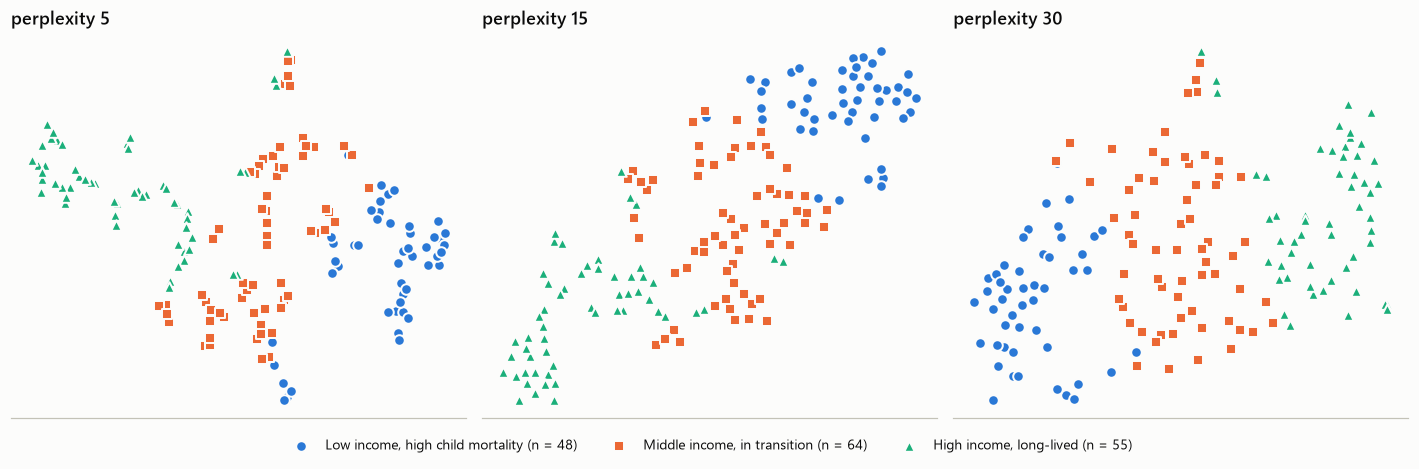

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, perp in zip(axes, (5, 15, 30)):
    Tp = TSNE(n_components=2, perplexity=perp, init="pca", learning_rate="auto", random_state=SEED).fit_transform(Z)
    scatter_clusters(ax, Tp, "", "", f"perplexity {perp}")
    ax.set_xticks([]); ax.set_yticks([])
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, loc="lower center", ncol=len(names), bbox_to_anchor=(0.5, -0.07), fontsize=9)
fig.tight_layout()
save_fig(fig, "country_tsne_perplexity.png")
plt.show()

## 6. Interpreting the clusters

### 6.1 Profile in original units
Median of each feature per cluster (medians because several features are skewed).

In [19]:
profile = X_raw.groupby(labels).median()
profile.index = [f"{i + 1}: {CLUSTER_NAMES[i]}" for i in range(K)]
profile.insert(0, "countries", np.bincount(labels))
profile.to_csv(REPORT_DIR / "country_cluster_profile.csv")
profile.style.format({"countries": "{:d}", "child_mort": "{:.1f}", "exports": "{:.1f}", "health": "{:.1f}", "imports": "{:.1f}",
                      "income": "{:,.0f}", "inflation": "{:.1f}", "life_expec": "{:.1f}", "total_fer": "{:.2f}", "gdpp": "{:,.0f}"})

,countries,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
"1: Low income, high child mortality",48,88.8,22.4,5.5,39.8,"1,860",7.4,60.8,5.04,758
"2: Middle income, in transition",64,20.5,38.8,5.3,42.5,"9,925",8.1,72.3,2.50,"4,530"
"3: High income, long-lived",55,5.5,46.2,8.7,48.7,"29,600",1.4,79.8,1.63,"26,900"


### 6.2 Which features define each cluster?
Cluster centres in standardised units: red = above the all-country average, blue = below (units are standard deviations of the transformed features).

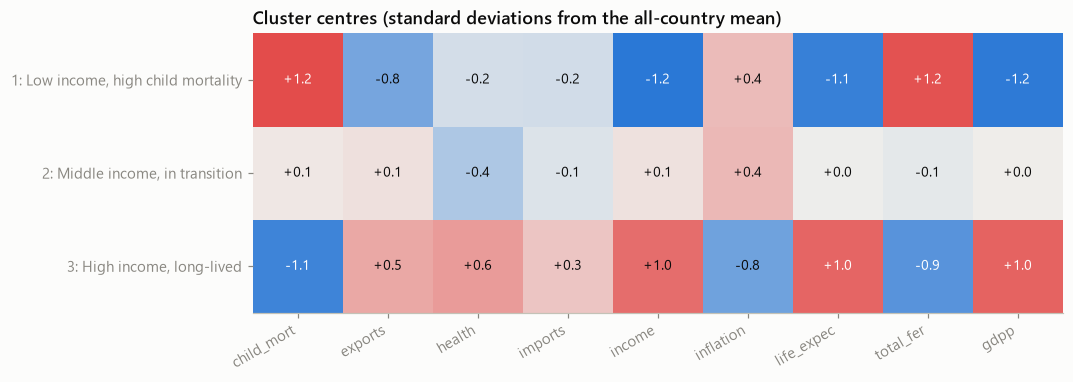

In [20]:
centre_tbl = pd.DataFrame(centers, columns=FEATURES, index=[f"{i + 1}: {CLUSTER_NAMES[i]}" for i in range(K)])
fig, ax = plt.subplots(figsize=(9.5, 1.2 + 0.7 * K))
lim = np.abs(centre_tbl.values).max()
im = ax.imshow(centre_tbl.values, cmap=DIVERGING, vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=30, ha="right")
ax.set_yticks(range(K), centre_tbl.index)
ax.grid(False)
for i in range(K):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{(0.0 if abs(centre_tbl.iloc[i, j]) < 0.05 else centre_tbl.iloc[i, j]):+.1f}", ha="center", va="center", fontsize=9, color=text_color_on(im.cmap(im.norm(centre_tbl.iloc[i, j]))))
ax.set_title("Cluster centres (standard deviations from the all-country mean)")
save_fig(fig, "country_cluster_centres.png")
plt.show()

### 6.3 Representative countries and full membership
Representatives are the five countries closest to each cluster centre in the 9-dimensional transformed space.

In [21]:
rep_rows, member_rows = [], []
for c in range(K):
    members = np.where(labels == c)[0]
    closest = members[np.argsort(dist_to_centre[members, c])[:5]]
    rep_rows.append({"cluster": f"{c + 1}: {CLUSTER_NAMES[c]}", "5 most typical countries": ", ".join(countries.loc[closest, "country"])})
    member_rows.append({"cluster": f"{c + 1}: {CLUSTER_NAMES[c]}", "n": len(members), "all countries": ", ".join(sorted(countries.loc[members, "country"]))})
display(pd.DataFrame(rep_rows).style.hide(axis="index"))
for r in member_rows:
    display(Markdown(f"**{r['cluster']}** ({r['n']} countries): {r['all countries']}"))

# borderline countries: lowest silhouette, with the second-closest cluster centre
dist_other = dist_to_centre.copy()
dist_other[np.arange(len(labels)), labels] = np.inf
borderline = (pd.DataFrame({"country": countries["country"], "assigned cluster": labels + 1, "silhouette": sil_samples,
                            "nearest other cluster": dist_other.argmin(axis=1) + 1})
                .sort_values("silhouette").head(8))
display(Markdown("**Borderline countries** (lowest silhouette; they sit between two clusters):"))
display(borderline.style.format({"silhouette": "{:.2f}"}).hide(axis="index"))

cluster,5 most typical countries
"1: Low income, high child mortality","Tanzania, Gambia, Burkina Faso, Malawi, Mali"
"2: Middle income, in transition","Jamaica, Suriname, Paraguay, Dominican Republic, St. Vincent and the Grenadines"
"3: High income, long-lived","Poland, Croatia, South Korea, Cyprus, Barbados"


**1: Low income, high child mortality** (48 countries): Afghanistan, Angola, Bangladesh, Benin, Burkina Faso, Burundi, Cambodia, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Cote d'Ivoire, Eritrea, Gambia, Ghana, Guinea, Guinea-Bissau, Haiti, India, Kenya, Kiribati, Lao, Lesotho, Liberia, Madagascar, Malawi, Mali, Mauritania, Micronesia, Fed. Sts., Mozambique, Myanmar, Nepal, Niger, Nigeria, Pakistan, Rwanda, Senegal, Sierra Leone, Solomon Islands, Sudan, Tajikistan, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Zambia

**2: Middle income, in transition** (64 countries): Albania, Algeria, Argentina, Armenia, Azerbaijan, Belarus, Belize, Bhutan, Bolivia, Botswana, Brazil, Brunei, Cape Verde, China, Colombia, Congo, Rep., Dominican Republic, Ecuador, Egypt, El Salvador, Equatorial Guinea, Fiji, Gabon, Georgia, Grenada, Guatemala, Guyana, Indonesia, Iran, Iraq, Jamaica, Jordan, Kazakhstan, Kuwait, Kyrgyz Republic, Libya, Malaysia, Moldova, Mongolia, Morocco, Namibia, Oman, Paraguay, Peru, Philippines, Romania, Russia, Samoa, Saudi Arabia, South Africa, Sri Lanka, St. Vincent and the Grenadines, Suriname, Thailand, Tonga, Tunisia, Turkey, Turkmenistan, Ukraine, Uruguay, Uzbekistan, Vanuatu, Venezuela, Vietnam

**3: High income, long-lived** (55 countries): Antigua and Barbuda, Australia, Austria, Bahamas, Bahrain, Barbados, Belgium, Bosnia and Herzegovina, Bulgaria, Canada, Chile, Costa Rica, Croatia, Cyprus, Czech Republic, Denmark, Estonia, Finland, France, Germany, Greece, Hungary, Iceland, Ireland, Israel, Italy, Japan, Latvia, Lebanon, Lithuania, Luxembourg, Macedonia, FYR, Maldives, Malta, Mauritius, Montenegro, Netherlands, New Zealand, Norway, Panama, Poland, Portugal, Qatar, Serbia, Seychelles, Singapore, Slovak Republic, Slovenia, South Korea, Spain, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States

**Borderline countries** (lowest silhouette; they sit between two clusters):

country,assigned cluster,silhouette,nearest other cluster
Qatar,3,-0.01,2
Uruguay,2,-0.00,3
Maldives,3,0.01,2
Cambodia,1,0.01,2
"Congo, Rep.",2,0.01,1
United Arab Emirates,3,0.01,2
India,1,0.03,2
Bahrain,3,0.03,2


### 6.4 Interpretation
**How to read the picture.** In the PCA plot the three clusters are laid out as overlapping bands along PC1. PC1 is a *development axis*: child mortality (+0.43), fertility (+0.39) and inflation (+0.22) load on one side, and income, GDP per capita and life expectancy (about −0.41 to −0.42) on the other, so low-income, high-mortality countries sit on the right and wealthy, long-lived ones on the left. PC2 is mostly *trade openness* (imports +0.75, exports +0.55); it pulls a few trade hubs to the top of the plot but does not separate the clusters. The bands touch and overlap at their edges, which matches the modest silhouette (0.25) and the borderline countries listed in §6.3.

**1. Low income, high child mortality (48 countries, mean silhouette 0.28, the tightest group).** Median child mortality is 88.8 per 1,000 live births, life expectancy 60.8 years, fertility 5.0 children per woman, income $1,860 and GDP per capita $758. Typical members: Tanzania, Gambia, Burkina Faso, Malawi, Mali. It is made up mostly of sub-Saharan African countries together with Afghanistan, Bangladesh, Cambodia, Haiti, India, Myanmar, Nepal, Pakistan, Yemen and some Pacific island states. These are the countries with the weakest health and income outcomes in the data.

**2. Middle income, in transition (64 countries, mean silhouette 0.20, the loosest group).** Median child mortality is 20.5, life expectancy 72.3 years, fertility 2.5, income $9,925 and GDP per capita $4,530. Its centre lies within roughly 0.1 standard deviations of the all-country average on seven of the nine features; the exceptions are below-average health spending (−0.4 SD) and above-average inflation (+0.4 SD). It holds many emerging economies (Brazil, China, Indonesia, Turkey, Thailand, Russia, South Africa) and many Latin American and Central Asian countries. It also contains rich oil exporters (Kuwait, Saudi Arabia, Oman, Brunei, with incomes of $45,000–$81,000) whose health spending is low (2.6–4.3% of GDP per capita) and inflation high (11–17%) in this data, and Equatorial Guinea (income $33,700 but child mortality of 111). Incomes in this cluster range from $2,790 to $80,600, which is why it is the least cohesive: all eight of the most borderline countries in §6.3 have cluster 2 as either their own or their nearest other cluster.

**3. High income, long-lived (55 countries, mean silhouette 0.27).** Median child mortality is 5.5, life expectancy 79.8 years, fertility 1.6, income $29,600, GDP per capita $26,900, inflation 1.4% and health spending 8.7% of GDP per capita (the highest of the three). Typical members: Poland, Croatia, South Korea, Cyprus, Barbados. It covers most of Western and Northern Europe, North America, Japan, Australia and New Zealand, plus Qatar, the UAE and several upper-middle-income European countries (Bulgaria, Bosnia and Herzegovina, Serbia). Its top-left tail is the group of trade hubs Singapore, Luxembourg, Malta and Ireland, whose exports are 100–200% of GDP per capita.

**What the three clusters mean.** They are best read as *low / middle / high tiers on a development continuum*, not as separated blocs. Income alone does not decide membership: the oil exporters above are placed by their health, inflation and trade profile as much as by income. The relation to the two-group view (§4.5) shows why the middle cluster exists: it takes the upper part of the "lower-income" group (25 countries) and the lower part of the "higher-income" group (39 countries), i.e. it is a band straddling the single cut that k = 2 would make. That is why k = 2 scores a higher silhouette (a single cut is simple), while k = 3 conveys more.

### 6.5 Cross-check with DBSCAN
DBSCAN looks for dense regions separated by sparse gaps and labels isolated points as noise. It needs two parameters, chosen by a stated rule: `min_samples = 5` (a small neighbourhood, since there are only 167 countries) and `eps` at the knee of the sorted 5th-nearest-neighbour distance plot (chord method, as for the elbow above).

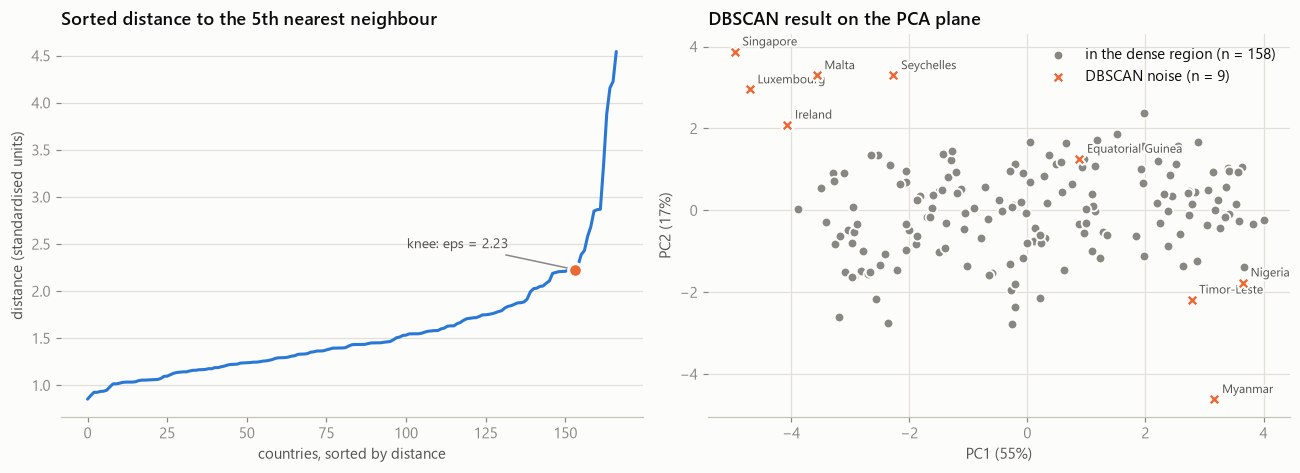

DBSCAN (eps = 2.23, min_samples = 5) finds **1 dense cluster(s)** and **9 noise points**: Equatorial Guinea, Ireland, Luxembourg, Malta, Myanmar, Nigeria, Seychelles, Singapore, Timor-Leste. By K-Means cluster, the noise points are: cluster 1 → 3, cluster 2 → 1, cluster 3 → 5.

**Sensitivity:** `min_samples` 4–8, with `eps` at the knee and up to 30% above it.

min_samples,eps,dense clusters,noise points
4,1.81,1,19
4,2.08,1,10
4,2.35,1,7
5,2.23,1,9
5,2.56,1,7
5,2.90,1,3
6,1.97,1,15
6,2.26,1,7
6,2.56,1,7
8,2.10,1,13


In [22]:
def k_distance_knee(min_samples):
    """Sorted distance of every country to its min_samples-th nearest neighbour, and the knee (chord method) of that curve."""
    kd = np.sort(NearestNeighbors(n_neighbors=min_samples).fit(Z).kneighbors(Z)[0][:, -1])
    x = np.linspace(0, 1, len(kd))
    y_ = (kd - kd.min()) / (kd.max() - kd.min())
    i = int(np.argmax(x - y_))
    return kd, i, float(kd[i])


MIN_SAMPLES = 5
kdist, knee, eps = k_distance_knee(MIN_SAMPLES)

dbs = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit(Z)
n_db_clusters = len(set(dbs.labels_)) - (1 if -1 in dbs.labels_ else 0)
noise = np.where(dbs.labels_ == -1)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].plot(np.arange(len(kdist)), kdist, color=BLUE)
axes[0].scatter([knee], [eps], s=80, color=ORANGE, edgecolor=SURFACE, linewidth=2, zorder=5)
axes[0].annotate(f"knee: eps = {eps:.2f}", (knee, eps), xytext=(-110, 14), textcoords="offset points", fontsize=9, color=INK_2,
                 arrowprops=dict(arrowstyle="-", color=MUTED, lw=1))
axes[0].set_title(f"Sorted distance to the {MIN_SAMPLES}th nearest neighbour")
axes[0].set_xlabel("countries, sorted by distance"); axes[0].set_ylabel("distance (standardised units)")
axes[0].grid(axis="x", visible=False)

axes[1].scatter(P[dbs.labels_ >= 0, 0], P[dbs.labels_ >= 0, 1], s=40, color=MUTED, edgecolor=SURFACE, linewidth=1.2, label=f"in the dense region (n = {int((dbs.labels_ >= 0).sum())})", zorder=3)
axes[1].scatter(P[noise, 0], P[noise, 1], s=60, color=ORANGE, marker="X", edgecolor=SURFACE, linewidth=1.2, label=f"DBSCAN noise (n = {len(noise)})", zorder=4)
for i in noise:
    axes[1].annotate(countries.loc[i, "country"], (P[i, 0], P[i, 1]), xytext=(5, 4), textcoords="offset points", fontsize=8, color=INK_2,
                     path_effects=[pe.withStroke(linewidth=2.5, foreground=SURFACE)])
axes[1].set_title("DBSCAN result on the PCA plane")
axes[1].set_xlabel(f"PC1 ({evr[0]:.0%})"); axes[1].set_ylabel(f"PC2 ({evr[1]:.0%})")
axes[1].legend(loc="best")
fig.tight_layout()
save_fig(fig, "country_dbscan.png")
plt.show()

noise_by_cluster = pd.Series(labels[noise] + 1).value_counts().sort_index()
display(Markdown(
    f"DBSCAN (eps = {eps:.2f}, min_samples = {MIN_SAMPLES}) finds **{n_db_clusters} dense cluster(s)** and **{len(noise)} noise points**: "
    f"{', '.join(countries.loc[noise, 'country'])}. "
    f"By K-Means cluster, the noise points are: {', '.join(f'cluster {k} → {v}' for k, v in noise_by_cluster.items())}."
))

# Is the "one dense region" result an accident of these two parameters? Try a small grid around them.
grid_rows = []
for ms in (4, 5, 6, 8):
    eps0 = k_distance_knee(ms)[2]
    for mult in (1.0, 1.15, 1.3):
        lab = DBSCAN(eps=eps0 * mult, min_samples=ms).fit_predict(Z)
        grid_rows.append({"min_samples": ms, "eps": eps0 * mult, "dense clusters": len(set(lab)) - (1 if -1 in lab else 0),
                          "noise points": int((lab == -1).sum())})
display(Markdown("**Sensitivity:** `min_samples` 4–8, with `eps` at the knee and up to 30% above it."))
display(pd.DataFrame(grid_rows).style.format({"eps": "{:.2f}"}).hide(axis="index"))

**What DBSCAN adds.** DBSCAN finds **one** dense region containing nearly all countries and sets aside nine as noise, and the sensitivity grid shows that this does not depend on the exact parameters. The noise points are economies that are extreme on one dimension: the trade hubs and small rich economies (Singapore, Luxembourg, Malta, Ireland, Seychelles) and Nigeria (inflation of 104), Myanmar (exports and imports close to 0% of GDP per capita), Timor-Leste (very high fertility together with high health spending) and Equatorial Guinea (income of $33,700 but child mortality of 111).

**Consequence for the main result.** There are no density gaps in this data that would point to a "natural" number of clusters: the countries form a continuum. This agrees with the PCA and t-SNE pictures (bands that touch), with the mid-0.2 silhouette scores, and with the stability results that fall off quickly beyond k = 5. The K-Means clusters should therefore be read as a useful segmentation of a continuum (§6.4), and DBSCAN's most useful contribution is the short list of unusual economies that pull K-Means centres.

## 7. Limitations
- **No ground truth.** Clusters cannot be scored against labels; silhouette, stability and interpretability are the only evidence, and silhouette values in the mid-0.2s indicate overlapping, not sharply separated, groups.
- **Choices shape the result.** The transform (Yeo–Johnson), the feature set, the exclusion of k = 2 (§4.1, rule 4) and K-Means' preference for compact, similar-sized groups all influence the outcome.
- **A continuum, not islands.** DBSCAN's behaviour (§6.5) indicates there are no clear density gaps; K-Means partitions a continuum into useful bands rather than discovering natural species of country.
- **Snapshot of 167 countries.** One time point, national averages that hide inequality within countries, and a handful of extreme economies (§2.3).
- **t-SNE is for viewing only.** Its axes carry no meaning and its picture changes with perplexity (§5.2).

In [23]:
assignments = countries[["country"]].assign(
    cluster=labels + 1, cluster_name=[CLUSTER_NAMES[l] for l in labels],
    PC1=P[:, 0], PC2=P[:, 1], tSNE1=T[:, 0], tSNE2=T[:, 1], dbscan_noise=(dbs.labels_ == -1))
assignments.to_csv(REPORT_DIR / "country_clusters.csv", index=False)
print(f"Saved {len(assignments)} country assignments to {REPORT_DIR / 'country_clusters.csv'}")

Saved 167 country assignments to ..\reports\country_clusters.csv
